In [5]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame for easier manipulation (optional, but good practice)
df = housing.frame # type: ignore

print("Data Loaded Successfully.")
print(df.head())

Data Loaded Successfully.
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [6]:
# Separate features (X) and target (y)
X = df.drop(columns=['MedHouseVal']) # Features are all columns except the target
y = df['MedHouseVal']                # Target variable (Median House Value in 100k USD)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for Linear Regression performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)


In [7]:
# Initialize the Linear Regression model
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train_scaled, y_train)

print("Linear Regression Model Trained.")
print(f"Model Intercept: {lin_reg.intercept_:.2f}")

Linear Regression Model Trained.
Model Intercept: 2.07


In [8]:
# Make predictions on the test set
y_pred = lin_reg.predict(X_test_scaled)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared Score (R2): 0.5758


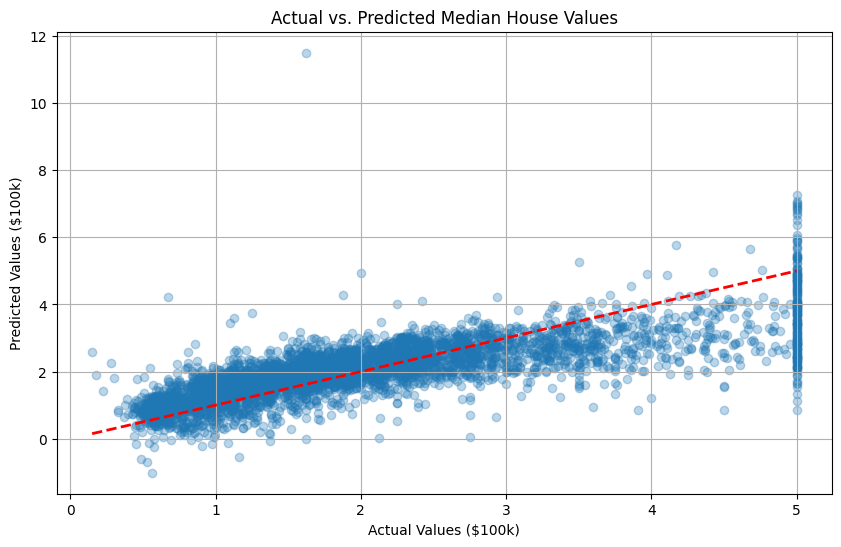

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal Line (Ideal prediction)
plt.title('Actual vs. Predicted Median House Values')
plt.xlabel('Actual Values ($100k)')
plt.ylabel('Predicted Values ($100k)')
plt.grid(True)
plt.show()

In [10]:
import joblib

joblib.dump("hello world", "model.pkl")

['model.pkl']